# 📚 1-qadam: Kerakli kutubxonalarni yuklab olish

Ushbu bosqichda biz ma'lumotlarni yuklash, tahlil qilish va modellarni qurish uchun kerakli barcha Python kutubxonalarini chaqiramiz.

Yuklanadigan asosiy kutubxonalar:
- **Seaborn** va **Matplotlib** — ma'lumotlarni vizual ko‘rsatish uchun.
- **LinearRegression** va **LogisticRegression** — chiziqli va logistik regressiya modellarini qurish uchun.
- **MinMaxScaler** va **StandardScaler** — ma'lumotlarni normallashtirish va standartlashtirish uchun.
- **Scikit-learn metrics** — model natijalarini baholash (MAE, RMSE, R2, F1-score va boshqalar).

Quyidagi kod yordamida kutubxonalarni yuklab olamiz:

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.distutils.conv_template import header
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
    mean_squared_error,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 📚 2-qadam: Ma'lumotlar to'plamini yuklash va birlashtirish

Ushbu qadamda UCI Machine Learning Repository'dan sharob sifati ([Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality)) ma'lumotlar to'plamini yuklaymiz.

Yuklangan ma'lumotlar:
- **X** — xususiyatlar (atributlar)
- **y** — maqsadli o'zgaruvchi (sifat balli)

Xususiyatlar va maqsadli o'zgaruvchini `pandas` ma'lumotlar to'plamiga birlashtirib, keyingi tahlillar uchun umumiy `DataFrame` hosil qilamiz.

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

df = X.join(y)

# 📚 3-qadam: Ma'lumotlarni vizual va statistik tahlil qilish (EDA)

Ushbu bosqichda ma'lumotlar to'plamini chuqurroq o'rganish uchun **Exploratory Data Analysis (EDA)** o'tkazamiz.

EDA maqsadlari:
- Ma'lumotlar tuzilmasini ko‘rish va ma'lumot turlarini aniqlash (`info()`).
- Ma'lumotlar to'plamining birinchi qatorlarini ko‘rib chiqish (`head()`).
- Bo‘sh (NULL) qiymatlarni aniqlash (`isnull().sum()`).
- Statistik tavsifni ko‘rish (`describe()`).
- Atributlar (xususiyatlar) taqsimotini ko‘rish (histogrammalar).
- Atributlar o‘rtasidagi bog‘liqlik va korrelatsiyalarni aniqlash (pairplot va korrelatsiya matritsasi).

Quyidagi bosqichlarni bajaramiz:
- **head()** — ma'lumotlarning birinchi 5 qatorini ko‘rish.
- **info()** — ustunlarning turi va bo‘sh qiymatlar soni.
- **isnull().sum()** — bo‘sh qiymatlar mavjudligini tekshirish.
- **describe()** — asosiy statistik ko‘rsatkichlar.
- **Histograms** — atributlar taqsimotini ko‘rsatish.
- **Pairplot** — atributlar o‘rtasidagi munosabatlarni vizual ko‘rsatish.
- **Correlation Matrix (Issiqlik xaritasi)** — atributlar o‘rtasidagi bog‘liqlik va korrelatsiyani aniqlash.

Bu tahlillar orqali ma'lumotlar tuzilmasi va tendensiyalar haqida to‘liq tasavvur hosil qilamiz hamda modeling uchun zarur bo‘lgan qarorlarni qabul qilamiz.

In [14]:
df['High_quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

## 🎯 Ma'lumotlar va maqsadli o'zgaruvchilarni aniqlash

Sharob sifatiga oid ma'lumotlar to‘plamini ko‘rib chiqqach, asosiy maqsadli o‘zgaruvchi sifatida **`quality`** ustunini tanladik:
- **`quality`** — uzluksiz (`continuous`) integer qiymat, sharob sifatining balli (0 dan 10 gacha).
- **Regression (chiziqli regressiya)** uchun foydalaniladi.

Logistik regressiya uchun esa yangi maqsadli o‘zgaruvchi yaratdik:
- **`High_quality`** — ikkilik (`binary`) integer o‘zgaruvchi:
  - `1` — sharob sifati yuqori (7 yoki undan baland).
  - `0` — sharob sifati oddiy (6 yoki past).
- **Classification (logistik regressiya)** uchun foydalaniladi.

🧠 **Xulosa**:
- `quality` — regression uchun uzluksiz maqsadli o‘zgaruvchi.
- `High_quality` — classification uchun ikkilik maqsadli o‘zgaruvchi (`int` formatda).

In [15]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,High_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  High_quality          6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [42]:
df.isnull().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
High_quality            0
dtype: int64

In [43]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,High_quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.196552
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.397421
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


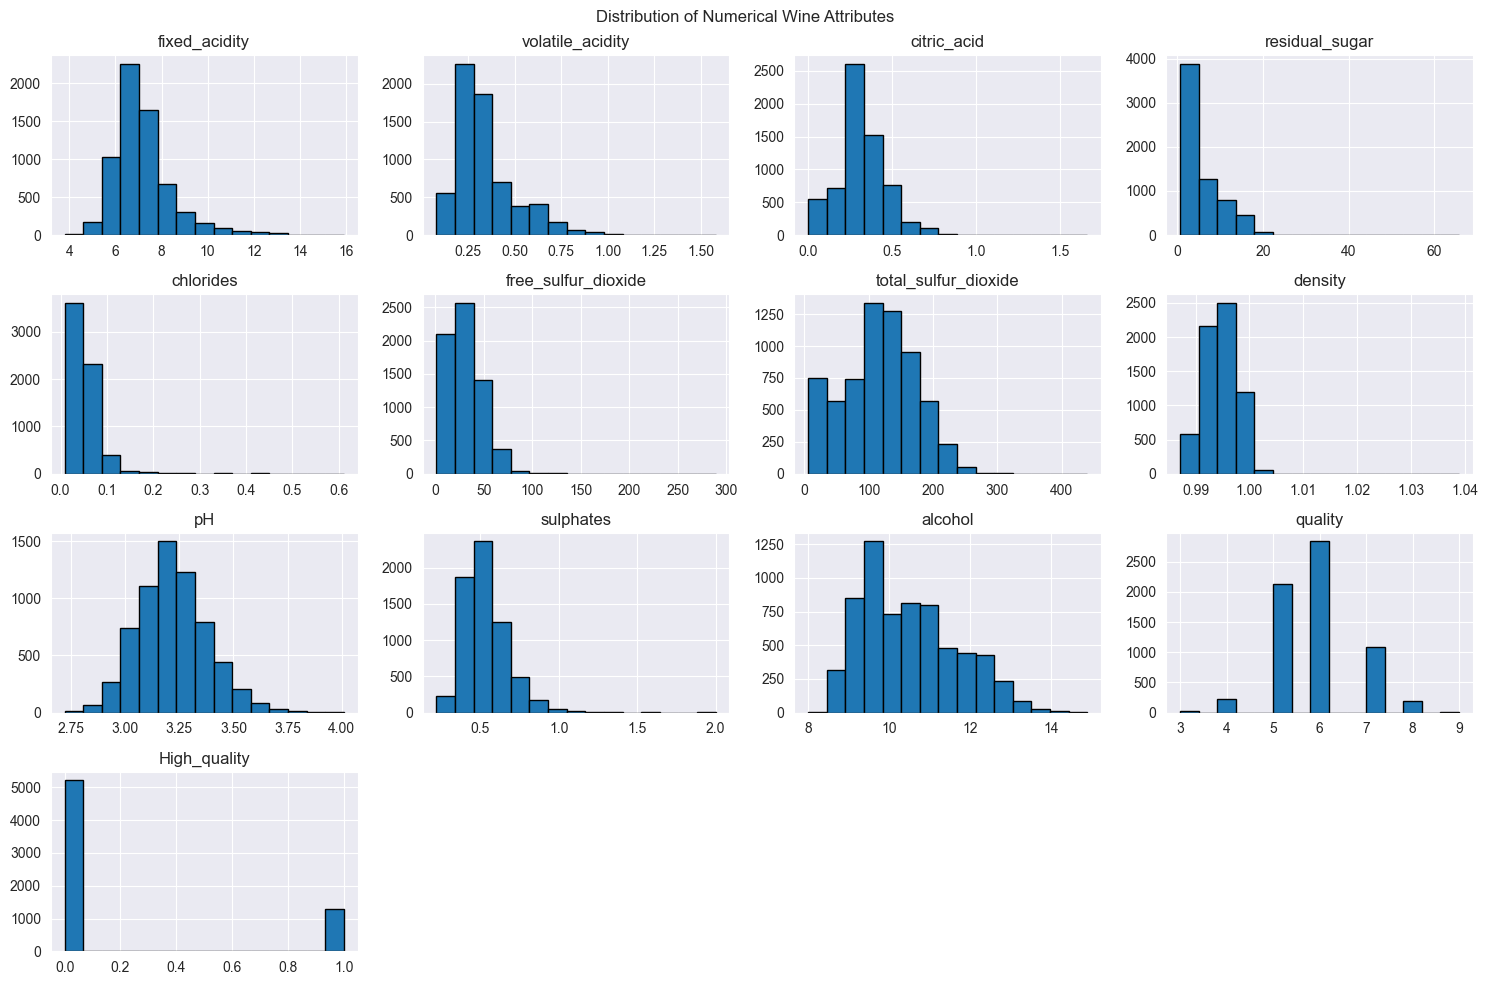

In [24]:
# Histograms
df.hist(bins=15, figsize=(15, 10), edgecolor='black')
plt.suptitle('Distribution of Numerical Wine Attributes')
plt.tight_layout()

plt.show()

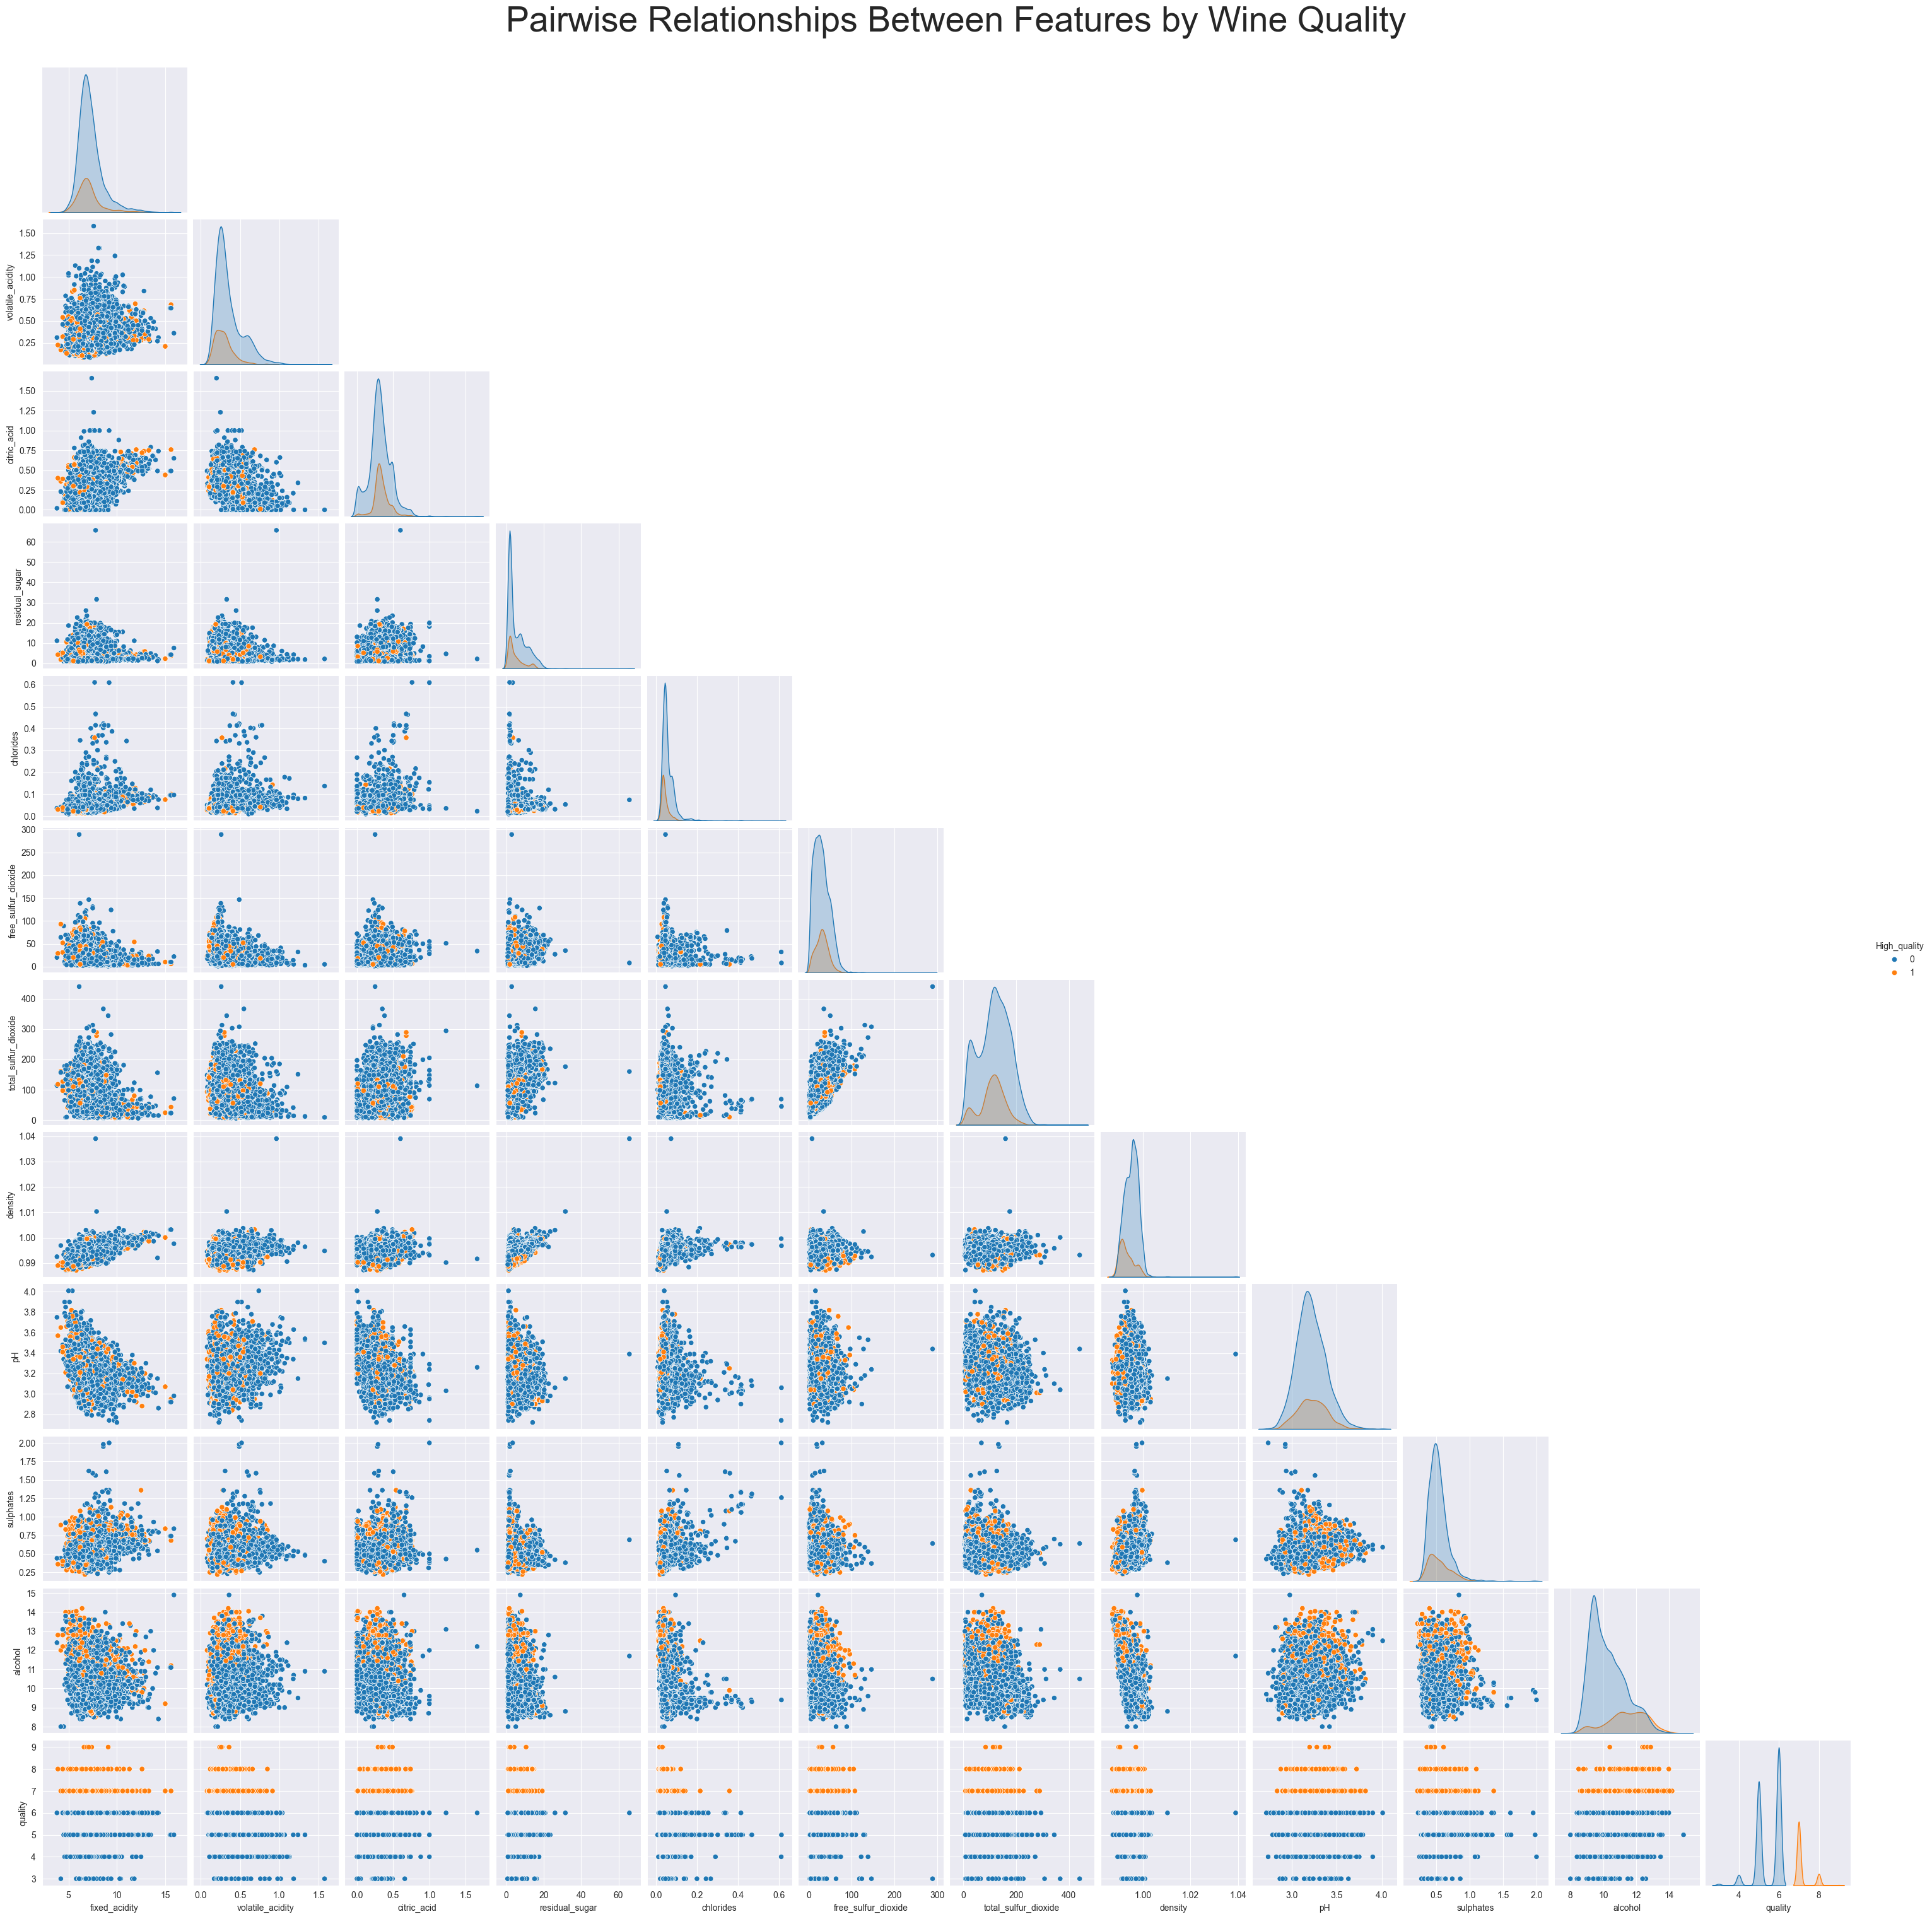

In [28]:
# Pairplot
sns.pairplot(df, hue='High_quality', corner=True)
plt.suptitle('Pairwise Relationships Between Features by Wine Quality', y=1.02, fontsize=40)
plt.show()

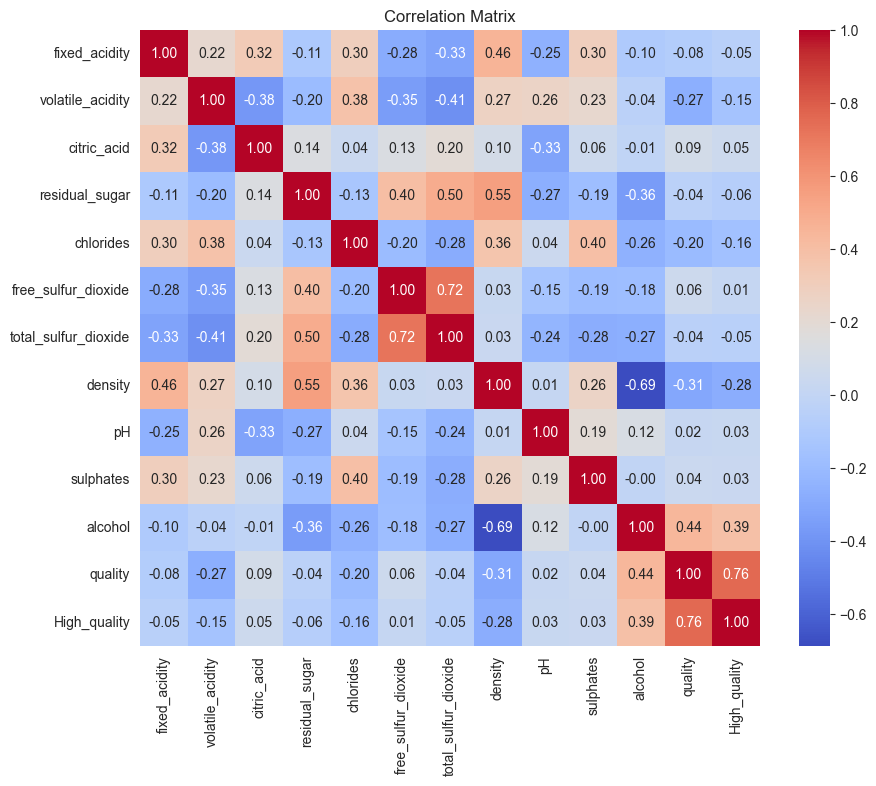

In [26]:
# Correlation matrix
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 🧠 4-qadam: Modellarni o‘rgatish va baholash

Ushbu bosqichda ma'lumotlar asosida regressiya va klassifikatsiya modellarini quramiz va ularni baholaymiz.

Modellash bosqichlari:
- **Chiziqli regressiya (Linear Regression)**:
  - Maqsad: sharob sifatini (quality) aniq bashorat qilish.
  - `alcohol` atributidan foydalanib oddiy chiziqli regressiya va barcha atributlardan foydalanib ko‘p o‘zgaruvchili chiziqli regressiya (Multiple Linear Regression) quramiz.
- **Logistik regressiya (Logistic Regression)**:
  - Maqsad: sharobning sifati yuqori (`High_quality = 1`) yoki past (`High_quality = 0`) ekanini klassifikatsiya qilish.
  - Barcha atributlardan foydalanib, ikkilik klassifikatsiya modelini quramiz.

Baholash metrikalari:
- **Regression** uchun:
  - `R2 Score` — modelning aniqlik darajasi.
  - `MAE`, `MSE`, `RMSE`, `MAPE` — xato ko‘rsatkichlari.
- **Classification** uchun:
  - `Classification Report` — Precision, Recall, F1-score.
  - `Confusion Matrix` — to‘g‘ri va noto‘g‘ri klassifikatsiya soni.

📊 Modellar natijalarini baholab, ularning qanchalik samarali ishlashini tahlil qilamiz.

In [48]:
# Linear Regression

# Ma'lumotlarni normallashtirish uchun MinMaxScaler yaratamiz
min_max_scaler = MinMaxScaler()

# Maqsadli o'zgaruvchi (target variable) sifatida sharob sifati (quality)
y = df['quality']
# Model uchun faqat 'alcohol' ustunini xususiyat (feature) sifatida olamiz
X = df[['alcohol']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = min_max_scaler.fit_transform(X_train)
X_test_scaled = min_max_scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Model baholash metrikalari
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Baholash natijalarini chiqarish
print(f'R2: {r2 * 100:.2f}')
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}')
print(f'MSE: {mse:.2f}')

R2: 18.16
MAE: 0.61
RMSE: 0.78
MAPE: 0.11
MSE: 0.60


In [49]:
# Multiple Linear Regression

# Maqsadli o'zgaruvchi (target variable) sifatida sharob sifati (quality)
y = df['quality']
# Barcha ustunlardan 'quality' ni olib tashlab, qolganlarini xususiyat (features) sifatida olamiz
X = df.drop(columns=['quality'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = min_max_scaler.fit_transform(X_train)
X_test_scaled = min_max_scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Model baholash metrikalari
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Baholash natijalarini chiqarish
print(f'R2: {r2 * 100:.2f}')
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}')

R2: 61.22
MAE: 0.43
RMSE: 0.54
MAPE: 0.08



Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90      1048
           1       0.61      0.27      0.37       252

    accuracy                           0.82      1300
   macro avg       0.73      0.61      0.64      1300
weighted avg       0.80      0.82      0.80      1300



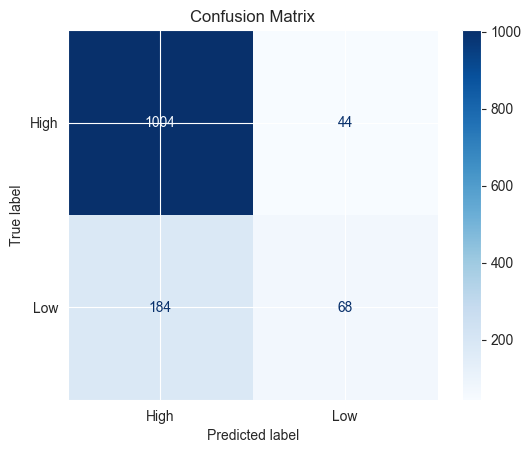

In [31]:
# StandardScaler yordamida ma'lumotlarni standarta keltirish uchun skaler yaratamiz
cat_scaler = StandardScaler()

# Xususiyatlar (features) sifatida 'quality' va 'High_quality' ustunlarisiz barcha ustunlarni olamiz
X_cat = df.drop(columns=['quality', 'High_quality'])
# Maqsadli o'zgaruvchi (target variable) sifatida 'High_quality' ustunini olamiz
y_cat = df['High_quality']

X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42)

X_cat_train_scaled = cat_scaler.fit_transform(X_cat_train)
X_cat_test_scaled = cat_scaler.transform(X_cat_test)

log_reg = LogisticRegression()
log_reg.fit(X_cat_train_scaled, y_cat_train)

y_pred_log = log_reg.predict(X_cat_test_scaled)

report = classification_report(y_cat_test, y_pred_log)

cm = confusion_matrix(y_cat_test, y_pred_log)

# Natijalarni chiqaramiz
print("\nClassification Report:\n", report)

# Confusion matrix vizualizatsiyasi
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["High", "Low"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()